In [2]:
import os
import pandas as pd
import numpy as np


In [3]:
filepath = "../../ARVI-IEO/IEO/DATA_ANALYSIS/unir_db_py/data_output/2005-2024.csv"
df = pd.read_csv(filepath, low_memory=False)
df["FechaCaptura"] = pd.to_datetime(df["FechaCaptura"], format="mixed") # Convert the str time to datetime
len(df)
#hay que escoger la bbox en todos igual
min_lon, min_lat, max_lon, max_lat = [-69.61, -60., -50., -32.45] #bbox of our study

In [4]:
df1 = df[["FechaCaptura","NombreBuque", "Lat", "Lon", "Peso", "EspecieFAO"]] # Select only the necessary columns
df1= df1.dropna(subset=["Lat", "Lon"])
df1[["Lat", "Lon"]] = df1[["Lat", "Lon"]].apply(lambda x: -abs(x)) #correccion de las posiciones
len(df1) #alrededor del 10% de los registros no tienen puntos valido, se podría ver para rescatar las capturas de estos registros con la ultima posición conocida del buque o mediante GFW.

df1["Lat"] = df1["Lat"].round(1)
df1["Lon"] = df1["Lon"].round(1)

df1 = df1[
    (df1['Lon'] >= min_lon) & (df1['Lon'] <= max_lon) &
    (df1['Lat'] >= min_lat) & (df1['Lat'] <= max_lat)
    ] #solo datos del area de interés 


df1['Fecha'] = df1['FechaCaptura'].dt.to_period('M')
df1_agg = (
    df1.groupby(["Fecha","EspecieFAO", "Lat", "Lon"], as_index=False)
      .agg(PesoTotal=('Peso', 'sum'))
)

df1_agg



,Fecha,EspecieFAO,Lat,Lon,PesoTotal
0,2006-01,CUS,-52.3,-63.2,720.0
1,2006-01,CUS,-51.9,-63.1,576.0
2,2006-01,CUS,-51.8,-63.4,2702.0
3,2006-01,CUS,-51.7,-63.5,4727.0
4,2006-01,CUS,-51.7,-63.4,1508.0
...,...,...,...,...,...
208908,2024-12,TOP,-51.7,-63.0,38.0
208909,2024-12,TOP,-46.5,-60.5,171.0
208910,2024-12,TOP,-46.0,-60.8,38.0
208911,2024-12,TOP,-45.9,-60.7,76.0


#### Creación de grid

In [5]:
res = 0.125
lat_grid = np.arange(min_lat, max_lat + res, res)
lon_grid = np.arange(min_lon, max_lon + res, res)

df1_agg['lat_bin'] = pd.cut(df1_agg['Lat'], bins=lat_grid, labels=lat_grid[:-1])
df1_agg['lon_bin'] = pd.cut(df1_agg['Lon'], bins=lon_grid, labels=lon_grid[:-1])

df1_grid = df1_agg.groupby(['Fecha', "lat_bin", "lon_bin", 'EspecieFAO'], observed=True)['PesoTotal'].sum().reset_index() #True no rellena con NaN cuando no hay datos

In [6]:
dsxr = (
    df1_grid
    .set_index(["Fecha", "lat_bin", "lon_bin", "EspecieFAO"]) #we define the xarray coordinates
    .to_xarray()
    .rename({"Fecha": "time", "lat_bin":"lat", "lon_bin":"lon", "EspecieFAO":"FAOspp"})
) #we convert the pandas dataframe to a xarray

# Define chunk sizes for dask, time in 12-month chunks, lat and lon full size, geartype and flag one at a chunk. 
chunks = {"time": 12, "lat": -1, "lon": -1, "FAOspp":1}
dsxr = dsxr.chunk(chunks)
dsxr = dsxr.assign_coords(time=dsxr.indexes["time"].to_timestamp())

dsxr = dsxr.reindex(lat=lat_grid, lon=lon_grid)
dsxr = dsxr.assign_coords(
    lat=dsxr["lat"].astype(str).astype(float),
    lon=dsxr["lon"].astype(str).astype(float)
)

c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\array\core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 72
  result = blockwise(


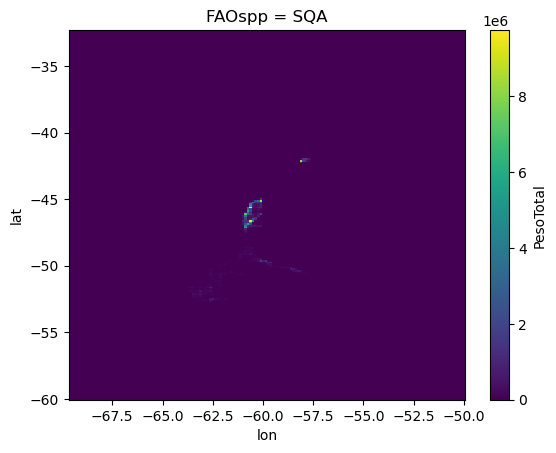

In [7]:
catch_data = dsxr["PesoTotal"].sel(FAOspp="SQA").sum(dim=["time"], skipna=True).compute()
# catch_data.where(catch_data > 10).plot()
catch_data.plot()

In [ ]:
SQA = dsxr.sel(FAOspp="SQA", drop=True)
SQA.to_netcdf("./data/processed/dynamic/SQA.nc")
presence_SQA = (SQA > 10000).astype(int)
presence_SQA = presence_SQA.rename({"PesoTotal": "presence"})
presence_SQA.to_netcdf("./data/processed/dynamic/presence_SQA.nc")

HKP = dsxr.sel(FAOspp="HKP", drop=True)
HKP.to_netcdf("./data/processed/dynamic/HKP.nc")
presence_HKP = (HKP > 10000).astype(int)
presence_HKP = presence_HKP.rename({"PesoTotal": "presence"})
presence_HKP.to_netcdf("./data/processed/dynamic/presence_HKP.nc")

In [ ]:
presence_SQA
print("Size", presence_SQA.sizes)
lat_diff = np.diff(presence_SQA.lat)
lon_diff = np.diff(presence_SQA.lon)
print("Spacing:")
print("Lat spacing:", np.unique(lat_diff), "Lon spacing:", np.unique(lon_diff))
print("Bounds:")
print(presence_SQA.lat.min().item(), presence_SQA.lat.max().item())
print(presence_SQA.lon.min().item(), presence_SQA.lon.max().item())

Size Frozen({'time': 216, 'lat': 222, 'lon': 158})
Spacing:
Lat spacing: [0.125] Lon spacing: [0.125]
Bounds:
-60.0 -32.375
-69.61 -49.985
